# Fitting classifiers

In [22]:
import pandas as pd
import numpy as np
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer, OneHotEncoder, MinMaxScaler
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_validate,
    cross_val_predict,
)
from sklearn import svm
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    roc_curve,
    precision_recall_curve,
    auc,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    average_precision_score,
)
from sklearn import set_config
from sklearn.svm import SVC
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.inspection import permutation_importance
import matplotlib.pyplot as plt
%matplotlib inline


In [23]:
original_df = pd.read_csv('tracks2026.csv')
df = original_df.copy()
df

,track_id,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5xmO5SbFOiVrRGrMQhL4Jk,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,5cF0dROlMOK5uNZtivgu50,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,4OQ9XGe11ckizN2EBnNED2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,6Grw9OtoslF9JrDJ6pgsQG,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,3fGpNiwYr981n72YY4DZvB,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,4pcpqfSn8tfm6vQMMZPjpM,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,1WM80A5a4xDtlndjqjZQIv,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,4drUfuJw6c9M5cXA8p7upO,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,6ULjJomtdRstnT9BPMAf9d,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


In [24]:
# Drop NaN values and trackid
df = df.dropna()
df = df.drop(columns = ["track_id"])
df

,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,44.0,203337,False,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,83.0,208786,False,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,49.0,262373,False,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,0.0,191733,False,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,41.0,283706,False,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,25.0,266133,False,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,52.0,223236,False,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,0.0,162009,False,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,58.0,120000,False,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


In [25]:
# Encode explicit-column
map_cat = {False: 0, True: 1}
df[['explicit']] = df[['explicit']].replace(map_cat)
df

C:\Users\pette\AppData\Local\Temp\ipykernel_6700\1726812226.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[['explicit']] = df[['explicit']].replace(map_cat)


,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,44.0,203337,0,0.608,0.553,10,-3.493,1,0.0271,0.3930,0.000000,0.1530,0.541,143.993,3,r-n-b
1,83.0,208786,0,0.775,0.613,3,-4.586,0,0.0542,0.1090,0.000023,0.1340,0.797,100.066,4,pop
2,49.0,262373,0,0.797,0.612,2,-9.043,0,0.0313,0.2710,0.000011,0.3140,0.919,118.162,4,synth-pop
3,0.0,191733,0,0.582,0.829,9,-3.517,1,0.1930,0.0522,0.000000,0.2640,0.716,90.959,4,indie-pop
4,41.0,283706,0,0.705,0.713,4,-6.676,0,0.0437,0.2600,0.000016,0.0499,0.498,129.899,4,synth-pop
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,25.0,266133,0,0.794,0.919,9,-3.037,1,0.0619,0.1540,0.000000,0.2480,0.963,133.550,4,synth-pop
1996,52.0,223236,0,0.667,0.629,0,-8.493,1,0.0324,0.1750,0.116000,0.0915,0.455,115.002,4,synth-pop
1997,0.0,162009,0,0.541,0.753,0,-6.512,1,0.0511,0.0677,0.000000,0.1080,0.572,149.743,4,indie-pop
1998,58.0,120000,0,0.853,0.511,7,-6.451,0,0.4220,0.1880,0.000000,0.2230,0.795,90.171,4,hip-hop


In [26]:
# New target variable. This could be seen as a data leak, but as median is global and quite robust, we can the median of the whole dataset.
median_popularity = df["popularity"].median()
df['popularity_binary'] = df["popularity"].apply(lambda x: 0 if x <= median_popularity else 1)
df = df.drop(columns=["popularity"])
# X and y
y = df['popularity_binary']
X = df.drop(columns=["popularity_binary"])
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, stratify=y)

In [55]:
# Let us perform the preprosessing, same as in data preparation

# Define column groups
numerical_cols = X.select_dtypes(include=[np.number]).columns
categorical_numerical = ['key', 'mode', 'time_signature', 'explicit']  # numerical but categorical
continuous_numerical = [col for col in numerical_cols if col not in categorical_numerical]

no_outlier_cols = ['valence', 'acousticness']
outlier_cols = [col for col in continuous_numerical if col not in no_outlier_cols]
passthrough_cols = [col for col in df.columns if col not in continuous_numerical]

# Split outlier columns into negative and positive value groups
outlier_cols_neg = [col for col in outlier_cols if df[col].min() < 0]
outlier_cols_pos = [col for col in outlier_cols if df[col].min() >= 0]

# Pipelines
preprocess_no_outliers = Pipeline([
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', StandardScaler())
])

preprocess_outliers_neg = Pipeline([
    ('scaler', RobustScaler())  
])
preprocess_outliers_pos = Pipeline([
     ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
     ('scaler', RobustScaler())
])
# Scale key and time_signature columns, as they have different scale than others
key_timesignature_cols = ["key", "time_signature"]
key_timesignature_pipeline = Pipeline(steps = [
    ('scaler', StandardScaler())
])
minmax_pipeline = Pipeline(steps = [
    ('log', FunctionTransformer(func=np.log1p, feature_names_out='one-to-one')),
    ('scaler', MinMaxScaler())
])
# Do OneHotEncoding here to avoid test set containing information about the track-genre categories in training set. 
# If unknown value, ignore
onehotencode_pipeline = Pipeline(steps = [
    ("onehotencode", OneHotEncoder(handle_unknown='ignore'))
])
preprocess_pipeline = ColumnTransformer(
    transformers=[
        ('no_outliers', preprocess_no_outliers, no_outlier_cols),
        ('outliers_neg', preprocess_outliers_neg, outlier_cols_neg),
        ('outliers_pos', preprocess_outliers_pos, outlier_cols_pos),
        ('key_time_signature', key_timesignature_pipeline, key_timesignature_cols),
        ("onehotencode", onehotencode_pipeline, ["track_genre"] )
    ],
    remainder='passthrough'
)
print(no_outlier_cols)
print(outlier_cols_neg)
print(outlier_cols_pos)
print(key_timesignature_cols)



['valence', 'acousticness']
['loudness']
['duration_ms', 'danceability', 'energy', 'speechiness', 'instrumentalness', 'liveness', 'tempo']
['key', 'time_signature']


In [ ]:
# Fit the pipe to training data to inspect how transformed features look like
preprocessing_results = preprocess_pipeline.fit_transform(X_train)

In [83]:
# Put transformed values into a dataframe
feature_names = preprocess_pipeline.get_feature_names_out()
df_transformed = pd.DataFrame(
    preprocessing_results,
    columns=feature_names
)
df_transformed

,no_outliers__valence,no_outliers__acousticness,outliers_neg__loudness,outliers_pos__duration_ms,outliers_pos__danceability,outliers_pos__energy,outliers_pos__speechiness,outliers_pos__instrumentalness,outliers_pos__liveness,outliers_pos__tempo,key_time_signature__key,key_time_signature__time_signature,onehotencode__track_genre_hip-hop,onehotencode__track_genre_indie-pop,onehotencode__track_genre_pop,onehotencode__track_genre_r-n-b,onehotencode__track_genre_synth-pop,remainder__explicit,remainder__mode
0,-0.955450,-0.984151,0.635844,-0.610785,-0.357755,-0.073676,-0.053436,-0.009996,0.426771,0.900419,-0.655449,0.206782,0.0,1.0,0.0,0.0,0.0,0.0,0.0
1,1.124129,0.493271,0.774477,-0.008791,0.714093,0.726924,-0.213473,-0.005585,0.068804,-0.335545,1.332999,0.206782,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.875793,0.217772,0.193724,0.268690,0.559952,0.681314,5.169606,0.003162,2.800248,1.012147,-0.087321,0.206782,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,0.974118,-0.281706,-0.276011,-1.339512,0.151761,0.687851,1.952148,-0.009996,1.943516,0.604920,0.480807,0.206782,0.0,0.0,0.0,1.0,0.0,0.0,1.0
4,-0.534839,1.305534,0.490237,0.044233,0.486728,0.003660,-0.211360,-0.009996,-0.108132,0.075001,1.332999,0.206782,1.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,-0.174658,0.740856,-0.617155,-1.379882,0.338367,-0.393338,0.109607,0.002953,-0.195623,-0.945072,-0.087321,0.206782,0.0,1.0,0.0,0.0,0.0,1.0,1.0
1564,0.186804,1.381544,-1.033054,1.049194,0.378182,-0.735033,-0.304541,3.305820,-0.046176,0.028199,0.480807,0.206782,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1565,1.424117,-1.150996,1.149093,-0.600565,-0.244837,0.949940,-0.173354,-0.009996,0.234718,0.028495,-1.507640,0.206782,0.0,0.0,0.0,0.0,1.0,0.0,1.0
1566,0.974118,-0.865580,0.115621,-1.529102,0.238006,-0.992759,-0.045045,-0.009996,-0.357300,1.478208,-0.087321,0.206782,0.0,1.0,0.0,0.0,0.0,0.0,1.0


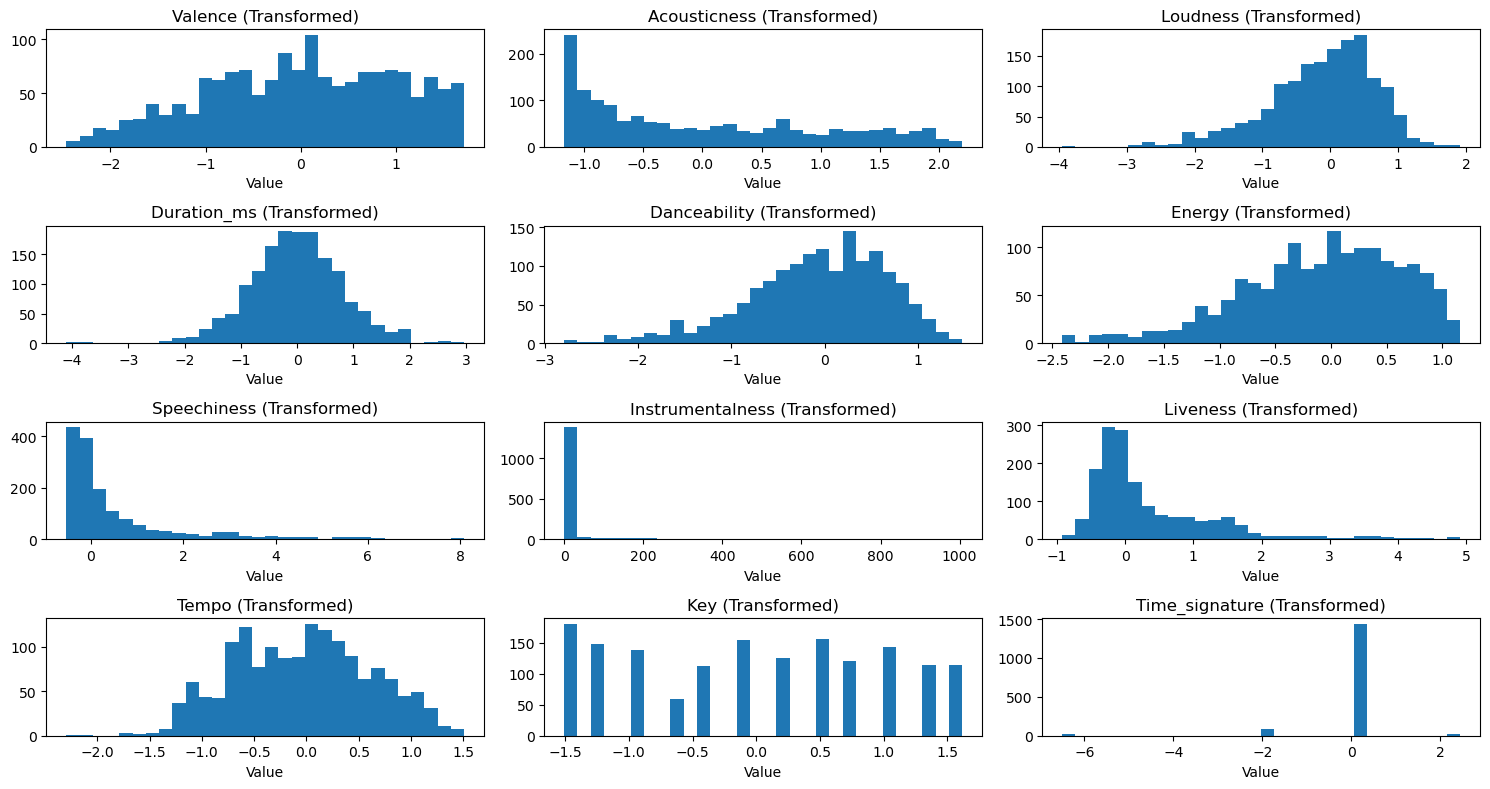

In [84]:
# Plot the TRANSFORMED data (not 0/1 values)
fig, axes = plt.subplots(4, 3, figsize=(15, 8))
axes[0, 0].hist(df_transformed['no_outliers__valence'], bins=30)
axes[0, 0].set_title('Valence (Transformed)')
axes[0, 0].set_xlabel('Value')

axes[0, 1].hist(df_transformed['no_outliers__acousticness'], bins=30)
axes[0, 1].set_title('Acousticness (Transformed)')
axes[0, 1].set_xlabel('Value')

axes[0, 2].hist(df_transformed['outliers_neg__loudness'], bins=30)
axes[0, 2].set_title('Loudness (Transformed)')
axes[0, 2].set_xlabel('Value')

axes[1, 0].hist(df_transformed['outliers_pos__duration_ms'], bins=30)
axes[1, 0].set_title('Duration_ms (Transformed)')
axes[1, 0].set_xlabel('Value')

axes[1, 1].hist(df_transformed['outliers_pos__danceability'], bins=30)
axes[1, 1].set_title('Danceability (Transformed)')
axes[1, 1].set_xlabel('Value')

axes[1, 2].hist(df_transformed['outliers_pos__energy'], bins=30)
axes[1, 2].set_title('Energy (Transformed)')
axes[1, 2].set_xlabel('Value')

axes[2, 0].hist(df_transformed['outliers_pos__speechiness'], bins=30)
axes[2, 0].set_title('Speechiness (Transformed)')
axes[2, 0].set_xlabel('Value')

axes[2, 1].hist(df_transformed['outliers_pos__instrumentalness'], bins=30)
axes[2, 1].set_title('Instrumentalness (Transformed)')
axes[2, 1].set_xlabel('Value')

axes[2, 2].hist(df_transformed['outliers_pos__liveness'], bins=30)
axes[2, 2].set_title('Liveness (Transformed)')
axes[2, 2].set_xlabel('Value')

axes[3, 0].hist(df_transformed['outliers_pos__tempo'], bins=30)
axes[3, 0].set_title('Tempo (Transformed)')
axes[3, 0].set_xlabel('Value')

axes[3, 1].hist(df_transformed['key_time_signature__key'], bins=30)
axes[3, 1].set_title('Key (Transformed)')
axes[3, 1].set_xlabel('Value')

axes[3, 2].hist(df_transformed['key_time_signature__time_signature'], bins=30)
axes[3, 2].set_title('Time_signature (Transformed)')
axes[3, 2].set_xlabel('Value')
plt.tight_layout()
plt.show()

In [ ]:
# Cross-validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
scoring = {
    "F1-score": "f1",
    "Precision": "precision",
    "Recall": "recall",
    "ROC_AUC": "roc_auc",
    "AP": "average_precision"
}

In [58]:
# SVM (slow af, don't know why)
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("svm", svm.SVC(probability=True))])

# Parameter grid
param_grid = {
    'svm__C': [0.1],
    'svm__gamma': [1],
    'svm__kernel': ['linear']
}

# Note that hyperparameters of the preprocessing transformers can also be included
# in the parameter grid. For simplicity, we do not tune them here.

svm_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
svm_search.fit(X_train, y_train) 

print(f"Best CV F1 = {svm_search.best_score_:.3f}")
print("Best parameters: ", svm_search.best_params_)

# store the best params and best model for later use
SVM_best_params = svm_search.best_params_
SVM_best_model = svm_search.best_estimator_
SVM_best_cv_f1 = svm_search.best_score_

Best CV F1 = 0.664
Best parameters:  {'svm__C': 0.1, 'svm__gamma': 1, 'svm__kernel': 'linear'}


In [59]:
# Random forest
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("r_forest", RandomForestClassifier())])
# Parameter grid
param_grid = {
    'r_forest__n_estimators': [10, 20, 30, 40],
    'r_forest__max_depth': [2, 4, 6, 8, 10, 12]
}

r_forest_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
r_forest_search.fit(X_train, y_train) 

print(f"Best CV F1 = {r_forest_search.best_score_:.3f}")
print("Best parameters: ", r_forest_search.best_params_)

# store the best params and best model for later use
r_forest_best_params = r_forest_search.best_params_
r_forest_best_model = r_forest_search.best_estimator_
r_forest_best_cv_f1 = r_forest_search.best_score_

Best CV F1 = 0.714
Best parameters:  {'r_forest__max_depth': 12, 'r_forest__n_estimators': 40}


In [60]:
# Gaussian (Normal) Naive Bayes
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("naive_bayes", GaussianNB())])
# Parameter grid
param_grid = {
    'naive_bayes__var_smoothing': [0.00000001, 0.00001, 0.001, 0.1]
}

NB_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
NB_search.fit(X_train, y_train) 

print(f"Best CV F1 = {NB_search.best_score_:.3f}")
print("Best parameters: ", NB_search.best_params_)

# store the best params and best model for later use
NB_best_params = NB_search.best_params_
NB_best_model = NB_search.best_estimator_
NB_best_cv_f1 = NB_search.best_score_

Best CV F1 = 0.653
Best parameters:  {'naive_bayes__var_smoothing': 1e-08}


In [61]:
# Logistic regression
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("logistic_reg", LogisticRegression())])
# Parameter grid, parameters suggested by Gemini
param_grid = {
    'logistic_reg__C': [0.01, 0.1, 1, 10, 100],
    'logistic_reg__penalty': ['l1', 'l2'],
    'logistic_reg__solver': ["liblinear", "saga"]
}

logistic_reg_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
logistic_reg_search.fit(X_train, y_train) 

print(f"Best CV F1 = {logistic_reg_search.best_score_:.3f}")
print("Best parameters: ", logistic_reg_search.best_params_)

# store the best params and best model for later use
logistic_reg_best_params = logistic_reg_search.best_params_
logistic_reg_best_model = logistic_reg_search.best_estimator_
logistic_reg_best_cv_f1 = logistic_reg_search.best_score_

Best CV F1 = 0.625
Best parameters:  {'logistic_reg__C': 1, 'logistic_reg__penalty': 'l2', 'logistic_reg__solver': 'liblinear'}


In [62]:
# Gradient Boosting Classifier
pipe = Pipeline(steps=[("preprocess", preprocess_pipeline), ("grad_boost", GradientBoostingClassifier())])
# Parameter grid, parameters suggested by Gemini
param_grid = {
    'grad_boost__learning_rate': [0.05, 0.1],
    'grad_boost__n_estimators': [100, 400],
    'grad_boost__max_depth': [3, 5],
    'grad_boost__min_samples_split': [2, 5],
    'grad_boost__subsample': [0.8,1.0]
}

grad_boost_search = GridSearchCV(
    pipe,
    param_grid,
    n_jobs=-1,
    cv=cv,
    scoring=scoring,
    refit="F1-score",
    return_train_score=False
)
grad_boost_search.fit(X_train, y_train) 

print(f"Best CV F1 = {grad_boost_search.best_score_:.3f}")
print("Best parameters: ", grad_boost_search.best_params_)

# store the best params and best model for later use
grad_boost_best_params = grad_boost_search.best_params_
grad_boost_best_model = grad_boost_search.best_estimator_
grad_boost_best_cv_f1 = grad_boost_search.best_score_

Best CV F1 = 0.704
Best parameters:  {'grad_boost__learning_rate': 0.1, 'grad_boost__max_depth': 5, 'grad_boost__min_samples_split': 2, 'grad_boost__n_estimators': 400, 'grad_boost__subsample': 0.8}


In [63]:
# Copied from the lab-exercise
# Compute CV metrics (mean ± std) for the *best* SVM, random forest and naive bayes models
models = {
    "SVM (best by F1)": SVM_best_model,
    "Random Forest (best by F1)": r_forest_best_model,
    "Gaussian Naive Bayes (best by F1)": NB_best_model,
    "Logistic regression (best by F1)": logistic_reg_best_model,
    "Gradient Boosting (best by F1)": grad_boost_best_model
}

cv_results = {}

for name, model in models.items():
    res = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False,
        n_jobs=-1
    )
    cv_results[name] = {m: res[f"test_{m}"] for m in scoring.keys()}

# Print a concise summary
for name, metrics_dict in cv_results.items():
    print("\n" + name)
    for m, vals in metrics_dict.items():
        print(f"  {m:9s}: mean={np.mean(vals):.3f}, std={np.std(vals):.3f}")




SVM (best by F1)
  F1-score : mean=0.664, std=0.030
  Precision: mean=0.592, std=0.036
  Recall   : mean=0.758, std=0.039
  ROC_AUC  : mean=0.657, std=0.045
  AP       : mean=0.631, std=0.041

Random Forest (best by F1)
  F1-score : mean=0.710, std=0.025
  Precision: mean=0.705, std=0.026
  Recall   : mean=0.715, std=0.044
  ROC_AUC  : mean=0.787, std=0.030
  AP       : mean=0.767, std=0.039

Gaussian Naive Bayes (best by F1)
  F1-score : mean=0.653, std=0.027
  Precision: mean=0.608, std=0.045
  Recall   : mean=0.709, std=0.029
  ROC_AUC  : mean=0.664, std=0.044
  AP       : mean=0.621, std=0.046

Logistic regression (best by F1)
  F1-score : mean=0.625, std=0.013
  Precision: mean=0.604, std=0.028
  Recall   : mean=0.649, std=0.028
  ROC_AUC  : mean=0.670, std=0.030
  AP       : mean=0.655, std=0.037

Gradient Boosting (best by F1)
  F1-score : mean=0.685, std=0.047
  Precision: mean=0.690, std=0.041
  Recall   : mean=0.682, std=0.069
  ROC_AUC  : mean=0.765, std=0.028
  AP       : 

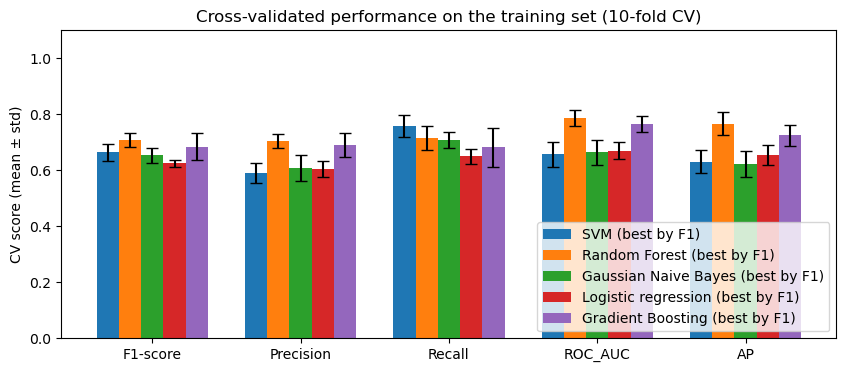

In [64]:
# Copied from the lab-exercise
# Plot of the mean and std of the metrics of different classifiers
metric_names = list(scoring.keys())
labels = list(cv_results.keys())

# means and stds
means = {lab: [np.mean(cv_results[lab][m]) for m in metric_names] for lab in labels}
stds  = {lab: [np.std(cv_results[lab][m]) for m in metric_names] for lab in labels}

x = np.arange(len(metric_names))
width = 0.15

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(x - width*2, means[labels[0]], width, yerr=stds[labels[0]], capsize=4, label=labels[0])
ax.bar(x - width, means[labels[1]], width, yerr=stds[labels[1]], capsize=4, label=labels[1])
ax.bar(x , means[labels[2]], width, yerr=stds[labels[2]], capsize=4, label=labels[2])
ax.bar(x + width, means[labels[3]], width, yerr=stds[labels[3]], capsize=4, label=labels[3])
ax.bar(x + width*2, means[labels[4]], width, yerr=stds[labels[4]], capsize=4, label=labels[4])

ax.set_xticks(x)
ax.set_xticklabels(metric_names, rotation=0)
ax.set_ylim(0, 1.1)
ax.set_ylabel("CV score (mean ± std)")
ax.set_title("Cross-validated performance on the training set (10-fold CV)")
ax.legend(loc="lower right")
plt.show()


### ROC curve

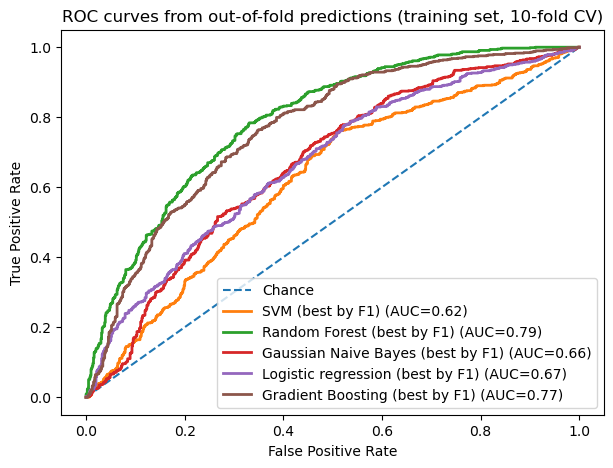

In [65]:
# Copied from the lab-exercise
# Out-of-fold ROC curves for the two best models (training set only)
plt.figure(figsize=(7, 5))
plt.plot([0, 1], [0, 1], linestyle="--", label="Chance")

for name, model in models.items():
    # Out-of-fold probability for class 1 (each point predicted by a model that did not train on it)
    oof_proba = cross_val_predict(model, X_train, y_train, cv=cv, method="predict_proba", n_jobs=-1)[:, 1]

    fpr, tpr, _ = roc_curve(y_train, oof_proba)
    auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f"{name} (AUC={auc_val:.2f})")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC curves from out-of-fold predictions (training set, 10-fold CV)")
plt.legend(loc="lower right")
plt.show()


### Evaluation by exercise notebook

In [66]:
best_model = r_forest_best_model
best_name = "Random Forest"
best_cv_f1 = r_forest_best_cv_f1

In [67]:
# Copied from the lab-exercise
def evaluate_model(X_eval, y_eval, model):
    # predicted probabilities for class 1
    probabilities = model.predict_proba(X_eval)[:, 1]

    # predicted class labels
    predicted = model.predict(X_eval)

    # confusion matrix
    cm = confusion_matrix(y_eval, predicted)

    # metrics
    acc = accuracy_score(y_eval, predicted)
    prec = precision_score(y_eval, predicted, zero_division=0)
    rec = recall_score(y_eval, predicted, zero_division=0)
    f1 = f1_score(y_eval, predicted, zero_division=0)

    # ROC curve + AUC
    fpr, tpr, _ = roc_curve(y_eval, probabilities)
    auc_val = auc(fpr, tpr)

    # PR curve + average_precision
    prc_precision, prc_recall, _ = precision_recall_curve(y_eval, probabilities)
    prc_ap = average_precision_score(y_eval, probabilities)

    return cm, acc, prec, rec, f1, fpr, tpr, auc_val, prc_precision, prc_recall, prc_ap
# Final evaluation on the held-out test set (used once for reporting)
test_cm, test_accuracy, test_precision, test_recall, test_f1_score, test_fpr, test_tpr, test_auc, test_prc_precision, test_prc_recall, test_prc_ap = evaluate_model(X_test, y_test, best_model)
cm_df = pd.DataFrame(
    test_cm,
    index=["Actual 0", "Actual 1"],
    columns=["Predicted 0", "Predicted 1"]
)

print("Confusion Matrix (Test Set):")
display(cm_df)

Confusion Matrix (Test Set):


,Predicted 0,Predicted 1
Actual 0,143,56
Actual 1,53,140


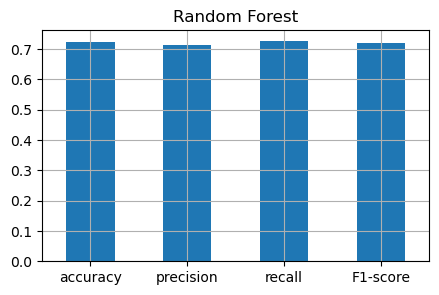

In [68]:
# Copied from the lab-exercise
metrics = np.array([test_accuracy, test_precision, test_recall, test_f1_score])
index = ['accuracy', 'precision', 'recall', 'F1-score']
df_metrics = pd.DataFrame({best_name: metrics}, index=index)
df_metrics.plot.bar(rot=0, figsize=(5, 3), legend=False, title=f"{best_name}")
plt.grid()
plt.show()

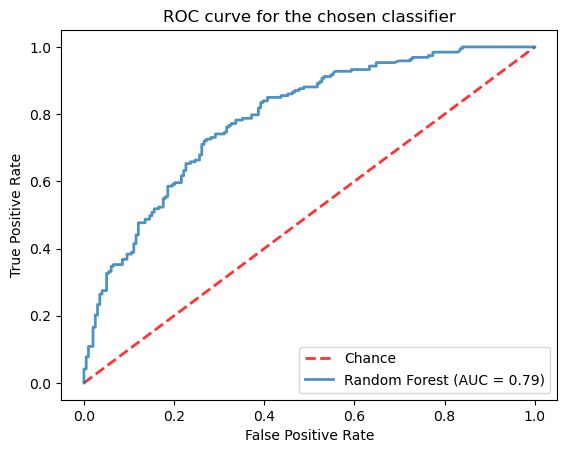

In [69]:
# Copied from the lab-exercise
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r', label='Chance', alpha=0.8)
plt.plot(test_fpr, test_tpr, lw=2, label=f'{best_name} (AUC = {test_auc:0.2f})', alpha=0.8)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve for the chosen classifier')
plt.legend(loc="lower right")
plt.show()

## Conclusion
Best model is Random Forest, providing approximately 70% accuracy, recall, precision and F1-score

## Feature importance
Let us use a method for model-agnostic global feature importance

In [ ]:
# Use permutation_importance, same way as in example. Let us do same to each model to get the complete picture.
r_forest_feature_importance_result = permutation_importance(
    r_forest_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
SVM_feature_importance_result = permutation_importance(
    SVM_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
logistic_reg_feature_importance_result = permutation_importance(
    logistic_reg_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
grad_boost_feature_importance_result = permutation_importance(
    grad_boost_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)
NB_feature_importance_result = permutation_importance(
    NB_best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

In [ ]:
# Turn importances to pd.Series
feature_names = X_test.columns
r_forest_importances = pd.Series(r_forest_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
grad_boost_importances = pd.Series(grad_boost_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
NB_importances = pd.Series(NB_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
logistic_reg_importances = pd.Series(logistic_reg_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)
SVM_importances = pd.Series(SVM_feature_importance_result.importances_mean, index=feature_names).sort_values(ascending=False)

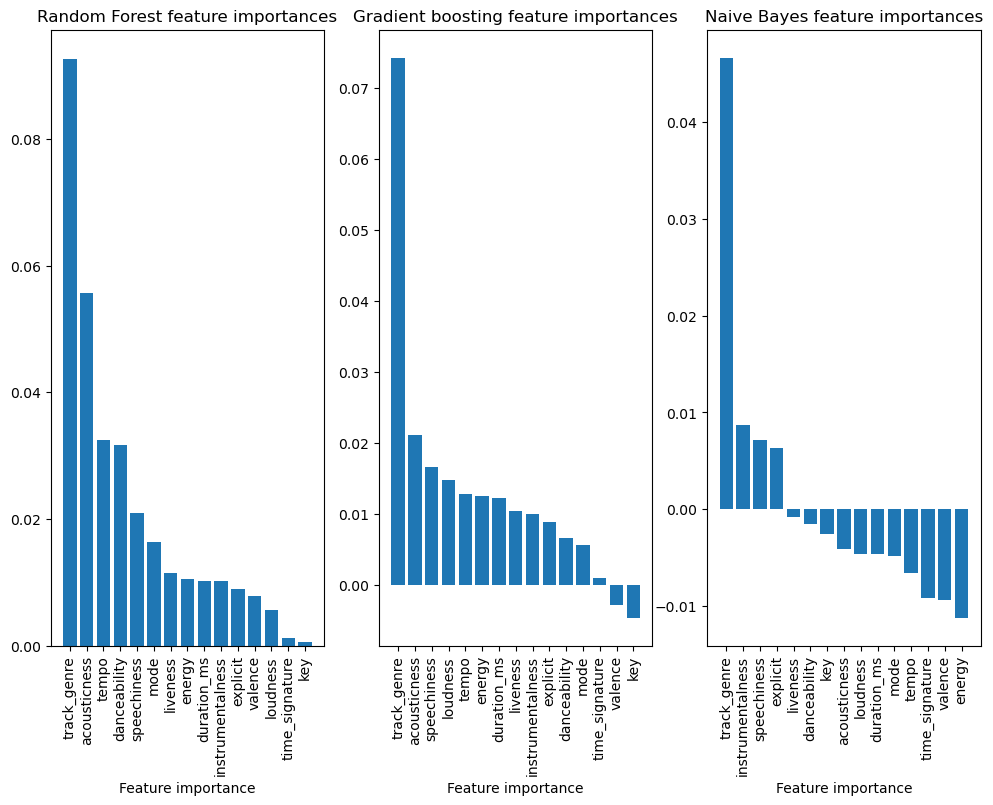

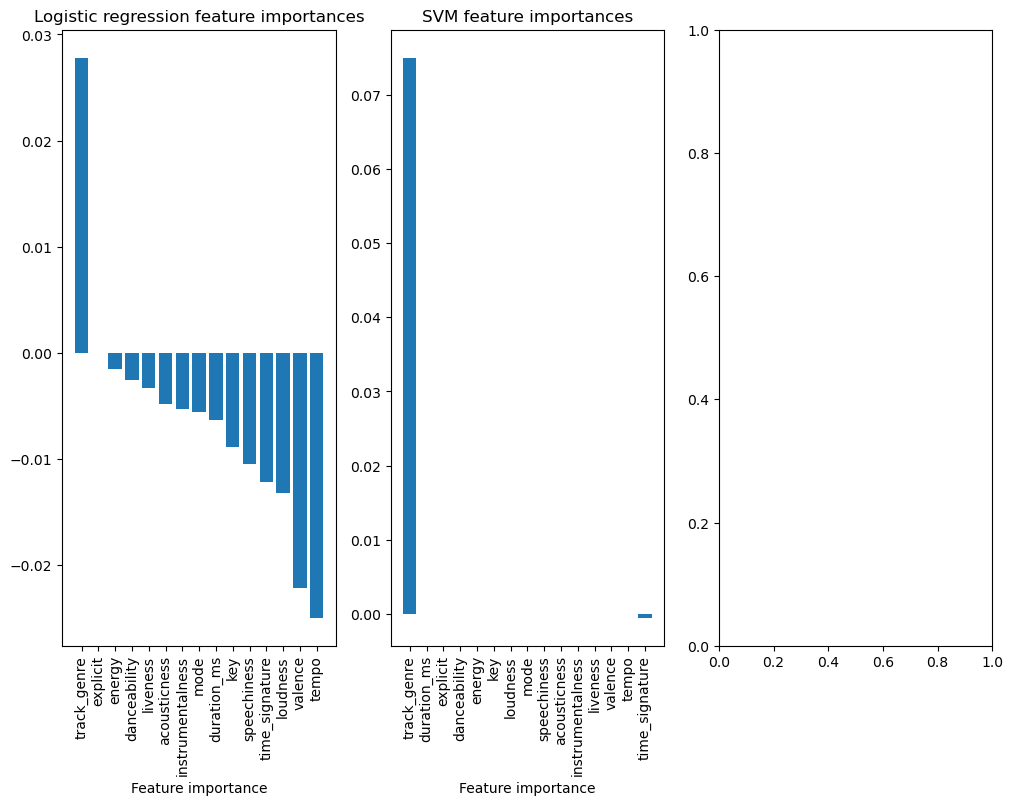

Feature importances of random forest model


track_genre         0.092602
acousticness        0.055612
tempo               0.032398
danceability        0.031633
speechiness         0.020918
mode                0.016327
liveness            0.011480
energy              0.010459
duration_ms         0.010204
instrumentalness    0.010204
explicit            0.008929
valence             0.007908
loudness            0.005612
time_signature      0.001276
key                 0.000510
dtype: float64

In [122]:
# Plot importances
fig, axes = plt.subplots(1, 3, figsize=(12, 8))
axes[0].bar(r_forest_importances.index, r_forest_importances)
axes[0].set_title('Random Forest feature importances')
axes[0].set_xlabel('Feature importance')
axes[0].tick_params(axis='x', labelrotation=90)
axes[1].bar(grad_boost_importances.index, grad_boost_importances)
axes[1].set_title('Gradient boosting feature importances')
axes[1].set_xlabel('Feature importance')
axes[1].tick_params(axis='x', labelrotation=90)
axes[2].bar(NB_importances.index, NB_importances)
axes[2].set_title('Naive Bayes feature importances')
axes[2].set_xlabel('Feature importance')
axes[2].tick_params(axis='x', labelrotation=90)
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 8))
axes2[0].bar(logistic_reg_importances.index, logistic_reg_importances)
axes2[0].set_title('Logistic regression feature importances')
axes2[0].set_xlabel('Feature importance')
axes2[0].tick_params(axis='x', labelrotation=90)
axes2[1].bar(SVM_importances.index,SVM_importances)
axes2[1].set_title('SVM feature importances')
axes2[1].set_xlabel('Feature importance')
axes2[1].tick_params(axis='x', labelrotation=90)
plt.show()
print("Feature importances of random forest model")
r_forest_importances

### Interpretation of feature importances of all models
As can be seen, track_genre is influencing the most to each of the model performance. Thus, it suggests that it has impact on the prediction of whether or not a song is popular.

### Interpretation of the feature importance of random forest model
Feature 'track_genre' seems to have the highest impact to the model performance, if it is shuffled (0.09). Also, features 'acousticness', 'tempo' and danceability seem to have higher importance than rest of the features. Shuffling of any feature do not lead to model performance decrease.